In [2]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper
import wikipedia

In [3]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv,description="Query arxiv papers")
print(arxiv.name)

arxiv


In [4]:
arxiv.invoke("Attention All Yopu Need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [5]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=2,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki,description="Query wiki papers")
print(wiki.name)

wikipedia


In [6]:
# 1. Set a descriptive User-Agent (Wikipedia blocks generic Python requests)
wikipedia.set_user_agent("MyLangChainBot/1.0 (sudheergundra@gmail.com)")

# 2. Set rate limiting to True to prevent getting IP banned
wikipedia.set_rate_limiting(True)

api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki, description="Query wiki papers")

print(wiki.invoke("Pawan Kalyan"))

Page: Pawan Kalyan
Summary: Konidela Pawan Kalyan (born Konidela Kalyan Kumar; 2 September 1971) is an Indian politician, actor, philanthropist, and martial artist serving as the 11th Deputy Chief Minister of Andhra Pradesh since June 2024. He is also the Minister of Panchayat Raj, Rural Development and Rural Water Supply; Environment, Forest, Science and Technology in the Government of Andhra Pradesh as MLA representing the Pitapuram constituency. He is the founder and president of the Janasena


In [7]:
from dotenv import load_dotenv
load_dotenv()
import os

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [9]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults()

In [10]:
tavily.invoke("Provide Me the recent AI news?")

[{'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth',
  'url': 'https://www.artificialintelligence-news.com',
  'content': 'Entertainment & Media\n\nOctober 30, 2025\n\n### Malaysia launches Ryt Bank, its first AI-powered bank\n\nFinance AI\n\nAugust 26, 2025\n\n### Google’s Veo 3 AI video creation tools are now widely available\n\nAI in Action\n\nJuly 29, 2025\n\n#### Computer Vision\n\n### Microsoft’s Majorana 2 quantum chip is also a case study for agentic AI in R&D\n\nInside AI\n\nJune 3, 2026\n\n### US and Japan announce sweeping AI and tech collaboration\n\nArtificial Intelligence\n\nApril 11, 2024\n\n### UK and Canada sign AI compute agreement\n\nArtificial Intelligence\n\nJanuary 31, 2024\n\n#### Machine Learning\n\n### MIT AI forecasts extreme weather without historical data\n\nEnvironment & Sustainability\n\nAugust 25, 2026\n\n### Samsung health AI models analyse wearable biosignal data\n\nHealthcare & Wellness AI\n\nAugust 14, 2026 [...] Healthcar

In [16]:
tools = [arxiv,wiki,tavily]

In [13]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-20b")

In [14]:
llm.invoke("Who is president of china?")

AIMessage(content='The President of the People’s Republic of China is **Xi\u202fJinping**.', additional_kwargs={'reasoning_content': 'We need to answer. The current president of China as of 2023 is Xi Jinping. But question: "Who is president of china?" Could be asking for current. According to latest info: Xi Jinping. But need to consider that "China" might refer to "People\'s Republic of China" or "China" as a generic term. It\'s likely the answer: Xi Jinping. Provide short answer.'}, response_metadata={'token_usage': {'completion_tokens': 110, 'prompt_tokens': 77, 'total_tokens': 187, 'completion_time': 0.133569035, 'completion_tokens_details': {'reasoning_tokens': 83}, 'prompt_time': 0.004389063, 'prompt_tokens_details': None, 'queue_time': 0.010292184, 'total_time': 0.137958098}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e99e93f2ac', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a068a2-d3f4-7090-

In [17]:
llm_with_tools=llm.bind_tools(tools=tools)

In [19]:
llm_with_tools.invoke("About anirudh ravichander")

AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants information about Anirudh Ravichander. Likely a music composer. We should search. Use tavily_search_results_json.', 'tool_calls': [{'id': 'fc_5a63d73e-011a-4435-b87f-06b87f240f6a', 'function': {'arguments': '{"query":"Anirudh Ravichander"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 212, 'total_tokens': 273, 'completion_time': 0.065297707, 'completion_tokens_details': {'reasoning_tokens': 29}, 'prompt_time': 0.013001593, 'prompt_tokens_details': None, 'queue_time': 0.249897694, 'total_time': 0.0782993}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_5979a0e1b7', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a068a5-692d-70f0-aa14-3294568900e8-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Anirudh Ravichand

In [20]:
llm_with_tools.invoke("What is the recent news on AI")

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the recent news on AI". They want recent news. We can search the web. Use tavily_search_results_json to get recent news. Use a query like "recent news on AI" or "latest AI news". Then provide a summary. Probably include top 3-5 items. Use the function.', 'tool_calls': [{'id': 'fc_7c9a2d9b-7de1-4225-a809-b1df02e5fa14', 'function': {'arguments': '{"query":"recent news on AI 2026"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 103, 'prompt_tokens': 212, 'total_tokens': 315, 'completion_time': 0.115859767, 'completion_tokens_details': {'reasoning_tokens': 70}, 'prompt_time': 0.010754338, 'prompt_tokens_details': None, 'queue_time': 0.269868249, 'total_time': 0.126614105}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_639a5351c8', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_pr

In [26]:
llm_with_tools.invoke("Teleugu Movies release in 2026")

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks "Telugu Movies release in 2026". They want a list of Telugu movies scheduled for release in 2026. We need up-to-date info. We can search the web. Use tavily_search_results_json.', 'tool_calls': [{'id': 'fc_d6b03e41-66b9-48f1-83c4-e52acbaf9bc5', 'function': {'arguments': '{"query":"Telugu movies release 2026"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 82, 'prompt_tokens': 213, 'total_tokens': 295, 'completion_time': 0.086832155, 'completion_tokens_details': {'reasoning_tokens': 49}, 'prompt_time': 0.014361414, 'prompt_tokens_details': None, 'queue_time': 0.348739382, 'total_time': 0.101193569}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_565badff47', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a068b3-d3f9-74d3-8e56-3d5a33b7fa75-0', tool_calls=

In [28]:
llm_with_tools.invoke("Early Life Of Actor Nani, wiki")

AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants "Early Life Of Actor Nani, wiki". They want info from Wikipedia. We can use the wikipedia function. Let\'s search.', 'tool_calls': [{'id': 'fc_5d6d0843-cc60-4556-a24f-d1e47432a0ec', 'function': {'arguments': '{"query":"Nani early life"}', 'name': 'wikipedia'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 213, 'total_tokens': 267, 'completion_time': 0.075587492, 'completion_tokens_details': {'reasoning_tokens': 29}, 'prompt_time': 0.022971069, 'prompt_tokens_details': None, 'queue_time': 0.494941591, 'total_time': 0.098558561}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_ef00694abe', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a068b8-a40b-7db2-8460-1a1e69d2f75d-0', tool_calls=[{'name': 'wikipedia', 'args': {'query': 'Nani early life'}, 'id': 'fc_5d6d0843-cc60-4556-a24f

In [29]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage # Human or AI message
from typing import Annotated # Labelling
from langgraph.graph.message import add_messages # Reducers in langgraph


In [32]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [30]:
# Chat Bot with LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

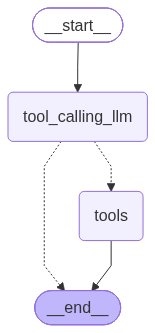

In [38]:
def tool_calling_llm(state: State):
    return{"messages":[llm_with_tools.invoke(state["messages"])]}

# Build a Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition,)
builder.add_edge("tools",END)
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [40]:
from langchain_core.messages import HumanMessage
messages = graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (fc_e4ec5f8b-9ee7-4f43-8e40-b9d11b26b74a)
 Call ID: fc_e4ec5f8b-9ee7-4f43-8e40-b9d11b26b74a
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [41]:
from langchain_core.messages import HumanMessage
messages = graph.invoke({"messages":HumanMessage(content="AED to INR present conversion rate")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

AED to INR present conversion rate
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_74755ea3-884d-414e-aca1-dc1f7472dd20)
 Call ID: fc_74755ea3-884d-414e-aca1-dc1f7472dd20
  Args:
    query: current AED to INR exchange rate
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AED INR | UAE Dirham Indian Rupee - Investing.com", "url": "https://www.investing.com/currencies/aed-inr", "content": "## People Also Watch\n\nGold\n\n4,507.35\n\nGC\n\n-0.50%\n\nXAU/AED\n\n16,362.2188\n\n-0.01%\n\nSilver\n\n68.098\n\nSI\n\n+0.46%\n\nUSD/INR\n\n95.111\n\n-0.27%\n\nEUR/USD\n\n1.1599\n\n+0.14%\n\n## FAQ\n\n### What Is the Current AED/INR Exchange Rate?\n\nThe current AED/INR exchange rate is 25.99, with a previous close of 26.02.\n\n### What Is the Daily Range for AED/IN

In [42]:
from langchain_core.messages import HumanMessage
messages = graph.invoke({"messages":HumanMessage(content="What is the capital of China?")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the capital of China?
================================== Ai Message ==================================

The capital of China is **Beijing**.


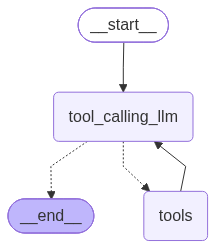

In [43]:
def tool_calling_llm(state: State):
    return{"messages":[llm_with_tools.invoke(state["messages"])]}

# Build a Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition,)
builder.add_edge("tools","tool_calling_llm")
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [47]:
from langchain_core.messages import HumanMessage
messages = graph.invoke({"messages":HumanMessage(content="Provide me Trisha wiki and please tell me 'Attention All You Need'")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me Trisha wiki and please tell me 'Attention All You Need'
================================== Ai Message ==================================
Tool Calls:
  wikipedia (fc_06cabf2a-b7b1-4965-8d59-19586cd85f40)
 Call ID: fc_06cabf2a-b7b1-4965-8d59-19586cd85f40
  Args:
    query: Trisha Wikipedia
================================= Tool Message =================================
Name: wikipedia

Page: Trisha Krishnan
Summary: Trisha Krishnan (born 4 May 1983) is an Indian actress known for her work primarily in Tamil and Telugu cinema. One of the highest-paid actresses in India, she has sustained a successful career as a leading actress for over two decades in Tamil cinema. Trisha gained prominence after winning the 1999 Miss Chennai pageant, which marked her entry into cinema. Often referred to as the "Queen of South India", she has received numerous accolades, including five Filmfare 
===================